<a href="https://colab.research.google.com/github/annazxc/annazxc.github.io/blob/main/Control_System_Revision_partner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control System Revision Partner

#[Ollama](https://ollama.com/)

Run LLM locally

## Install Ollama

In [ ]:
!curl -fsSL https://ollama.ai/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
############################################################################################# 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


## Run ollama server in the background

In [43]:
!nohup ollama serve &

nohup: appending output to 'nohup.out'


## Pull model

In [44]:
!ollama pull gemma3:4b

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest 
pulling aeda25e63ebd... 100% ▕▏ 3.3 GB                         
pulling e0a42594d802... 100% ▕▏  358 B                         
pulling dd084c7d92a3... 100% ▕▏ 8.4 KB                         
pulling 3116c5225075... 100% ▕▏   77 B                         
pulling b6ae5839783f... 100% ▕▏  489 B                         
verifying sha256 digest 
writing manifest 
success 


In [ ]:
!pip install openai
import openai
from openai import OpenAI

In [ ]:
!pip show openai

Name: openai
Version: 1.70.0
Summary: The official Python library for the openai API
Home-page: https://github.com/openai/openai-python
Author: 
Author-email: OpenAI <support@openai.com>
License: Apache-2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: anyio, distro, httpx, jiter, pydantic, sniffio, tqdm, typing-extensions
Required-by: 


In [ ]:
!ollama list #check if ollama server is running

NAME         ID              SIZE      MODIFIED       
gemma3:4b    a2af6cc3eb7f    3.3 GB    41 minutes ago    


### We are not really going to use the openAI API key<br> Since we are running locally on cloud using ollama<br>-->set randomly

In [ ]:
api_key = "ol" #dummy key

Default port is `11434` for ollama

In [ ]:
!ollama serve #the hosting place

2025/04/06 06:28:02 routes.go:1231: INFO server config env="map[CUDA_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: NO_PROXY: OLLAMA_CONTEXT_LENGTH:2048 OLLAMA_DEBUG:false OLLAMA_FLASH_ATTENTION:false OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_INTEL_GPU:false OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MODELS:/root/.ollama/models OLLAMA_MULTIUSER_CACHE:false OLLAMA_NEW_ENGINE:false OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NUM_PARALLEL:0 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://127.0.0.1 https://127.0.0.1 http://127.0.0.1:* https://127.0.0.1:* http://0.0.0.0 https://0.0.0.0 http://0.0.0.0:* https://0.0.0.0:* app://* file://* tauri://* vscode-webview://* vscode-file://*] OLLAMA_SCHED_SPREAD:false ROCR_VISIBLE_DEVICES: http_proxy: https_proxy:

In [ ]:
client = OpenAI(
    api_key=api_key,
    base_url="http://localhost:11434/v1"
)

## Revision Partner : Some Examples

Role :

* `system`: 人設
* `user`: 使用者
* `assistant`: Gemma3's response

In [ ]:
system = '''You are a knowledgeable and patient tutor +
revision partner specializing in Digital Control Systems.
Your goal is to assess and enhance the user’s understanding of key concepts
based on the textbook Digital Control System Analysis and Design
by Charles L. Phillips and H. Troy Nagle.
Please use approximately 20 words for each conversation, be clear and concise.'''

In [ ]:
prompt = "Please explain the fundamental concept of the pulse transfer function."

messages = [{"role":"system", "content":system},
            {"role": "user", "content":prompt}]

## Choose a model that fits the VRAM/RAM

In [ ]:
model = "gemma3:4b"

In [ ]:
response = client.chat.completions.create(
  model=model,
  messages=messages
)

In [ ]:
reply = response.choices[0].message.content
print(reply)

Okay, let’s tackle the pulse transfer function! Essentially, it’s a clever technique in digital control. It allows us to represent a continuous-time system’s response using discrete-time data. 

Specifically, it uses a *finite* number of samples to approximate an infinite response – a vital step for digital implementation.  Do you want me to elaborate on how it works mathematically, or would you prefer a real-world example to illustrate it?


# Since the response is quite long and hard to read, <br>add some code to make it a sentence a line

In [ ]:
prompt = '''Why is there a clear difference at the sample instants
            of the ramp response between continuous-time and discrete-time systems,
            even though their step responses are the same? '''

messages.append({"role": "user", "content":prompt})

In [ ]:
import re
response = client.chat.completions.create(
  model=model,
  messages=messages
)

reply = response.choices[0].message.content

sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', reply) if s]

formatted_reply = '\n'.join(sentences)

print(formatted_reply)

Okay, let’s tackle the pulse transfer function and that fascinating discrepancy you've identified.
The pulse transfer function, G(z), in discrete-time systems represents the system's impulse response, H(t), sampled at the sampling period, Ts.
Essentially, it dictates how the system reacts to a brief input pulse.
The clear difference arises from the sampling process itself.
It’s due to the abrupt discontinuity introduced at each sample instant.
This discontinuity means the system only "sees" the pulse's effect when it aligns with the sampling period, resulting in a staircase-like response.
Step responses, being continuous, don’t have this abrupt truncation, leading to a smoothly rising output.
Do you find that helpful so far?


## The above reply is longer than the first question
And I noticed a pattern:  
when I write longer prompts, LLMs tends to reply with longer answers.  
This got me curious — is the output length influenced by the input length?  

So, I asked ChatGPT about it.  
Below are some of the responses I received.


### Does Longer User Input Lead to Longer LLM Output?

**Summary:**  
Yes, in general, the longer the user input,

the more likely a language model (LLM) will produce a longer response — assuming no constraints are set.

---

#### ✅ Why This Happens:

1. **Context Matching and Continuity**  
   - LLMs tend to mirror the tone, structure, and detail level of the input.
   - A long, thoughtful prompt suggests the user expects a similarly detailed reply.

2. **Information Density and Relevance**  
   - Longer inputs usually include more information or multiple points.
   - The model tries to respond to each of those, naturally making the output longer.

3. **Training Data Patterns**  
   - During training, longer inputs are often paired with longer outputs (e.g., articles, essays, detailed Q&A).
   - The model learns to replicate that structure.


## Adding the reply / prompt to the conversation history<br>So they can remember the past

In [ ]:
messages.append({"role": "assistant", "content": reply})

- **Simulated Memory**: In a single conversation, <br>
the model “remembers” by appending (re-fed)
all previous messages into the prompt for each response.<br>
Therefore **Longer Chats = More Computation**:<br>
  - More tokens in context = more processing required.
  - Transformer architecture scales computationally with input length.


# Building the Revision partner model for longer conversation

# Wrap the above in a method to call anytime

In [ ]:
def chat(system, description, client, model):
    icon = "(๑¯∀¯๑) : "
    messages = [{"role": "system", "content": system},
                {"role": "assistant", "content": description}]
    print(icon + description + '\n')

    while True:
        prompt = input("You :")
        if 'bye' in prompt.lower():
            print('''(๑¯∀¯๑) : I'm glad we could chat. 😊
            Take care and see you around!''')
            break

        messages.append({"role": "user", "content": prompt})

        response = client.chat.completions.create(
            messages=messages,
            model=model
        )

        reply = response.choices[0].message.content

        sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', reply) if s]
        formatted_reply = '\n'.join(sentences)

        print(icon + formatted_reply + '\n')

        messages.append({"role": "assistant", "content": reply})


In [ ]:
chat(system= '''You are a knowledgeable and patient tutor +
                revision partner specializing in Digital Control Systems.
                Your goal is to assess and enhance the user’s understanding of key concepts
                based on the textbook Digital Control System Analysis and Design
                by Charles L. Phillips and H. Troy Nagle.
                Please use approximately 20 words for each conversation, be clear and concise.''',
    description= '''Welcome! Which concept would you like to revise?
                    I would try my best to help!''',


    client=client,
    model = "gemma3:4b")

(๑¯∀¯๑) : Welcome! Which concept would you like to revise?
                    I would try my best to help!

You :what is the pulse transfer function
(๑¯∀¯๑) : Okay, let's tackle the pulse transfer function.
Essentially, it describes how a sampled, periodic signal responds to a step input.
It's a key tool for analyzing and designing digital control systems, particularly those with periodic inputs.
Do you want to begin by discussing its definition, or would you like a simple example?

You :maybe an example
(๑¯∀¯๑) : Absolutely!
Let’s consider a simple case: a unity feedback system with a transfer function G(s) = 1/s(s+1).
This system represents a first-order system with a pole at s = -1.
Can you describe what the pulse transfer function *would* look like for this system?

You :you mean in z domain?
(๑¯∀¯๑) : Precisely!
The pulse transfer function is most readily represented and analyzed in the Z-domain.
Specifically, it’s the impulse response h[z] sampled at the sampling period, Ts.
Do 

# Some thoughts on the interaction
<font size=5 color="red">
The parameters of the model are limited to 4B (billion parameters),<br> so it might occasionally make mistakes or oversimplifications in complex or nuanced topics.

# Turn it into a web app! <br> Implemented using Gradio library

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.9 MB/s eta 0:00:00


In [ ]:
import gradio as gr

## Config the web app

In [ ]:
title = "Digital Control System Revision partner"
system= '''You are a knowledgeable and patient tutor +
                revision partner specializing in Digital Control Systems.
                Your goal is to assess and enhance the user’s understanding of key concepts
                based on the textbook Digital Control System Analysis and Design
                by Charles L. Phillips and H. Troy Nagle.
                Please use approximately 20 words for each conversation, be clear and concise.'''
description= '''Welcome! <br>Which concept would you like to revise? <br>I would try my best to help! (,,・ω・,,)'''


model = "gemma3:4b"

In [ ]:
init_messages = [{"role":"system",
             "content":system},
            {"role":"assistant",
            'content':description}]
state = gr.State(init_messages)

In [ ]:
def revision(prompt, messages):
    messages.append({"role": "user", "content": prompt})
    chat_completion = client.chat.completions.create(
        messages=messages,
        model=model,
        )
    reply = chat_completion.choices[0].message.content
    messages.append({"role": "assistant", "content": reply})
    return messages, messages

In [ ]:
with gr.Blocks(title=title) as bot:
    gr.Markdown(f"# 😊 {title}\n{description}")
    tutor = gr.Chatbot(type="messages")
    student = gr.Textbox(label="Ask anything ! (๑¯∀¯๑) :")
    state = gr.State(init_messages.copy())

    student.submit(fn=revision, inputs=[student, state], outputs=[tutor, state])

bot.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c92e150ded58bd674c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c92e150ded58bd674c.gradio.live


<font size=8>
Some testing results

<font size=5 color="red">
Recommand to run on public URL since the window is quite small.

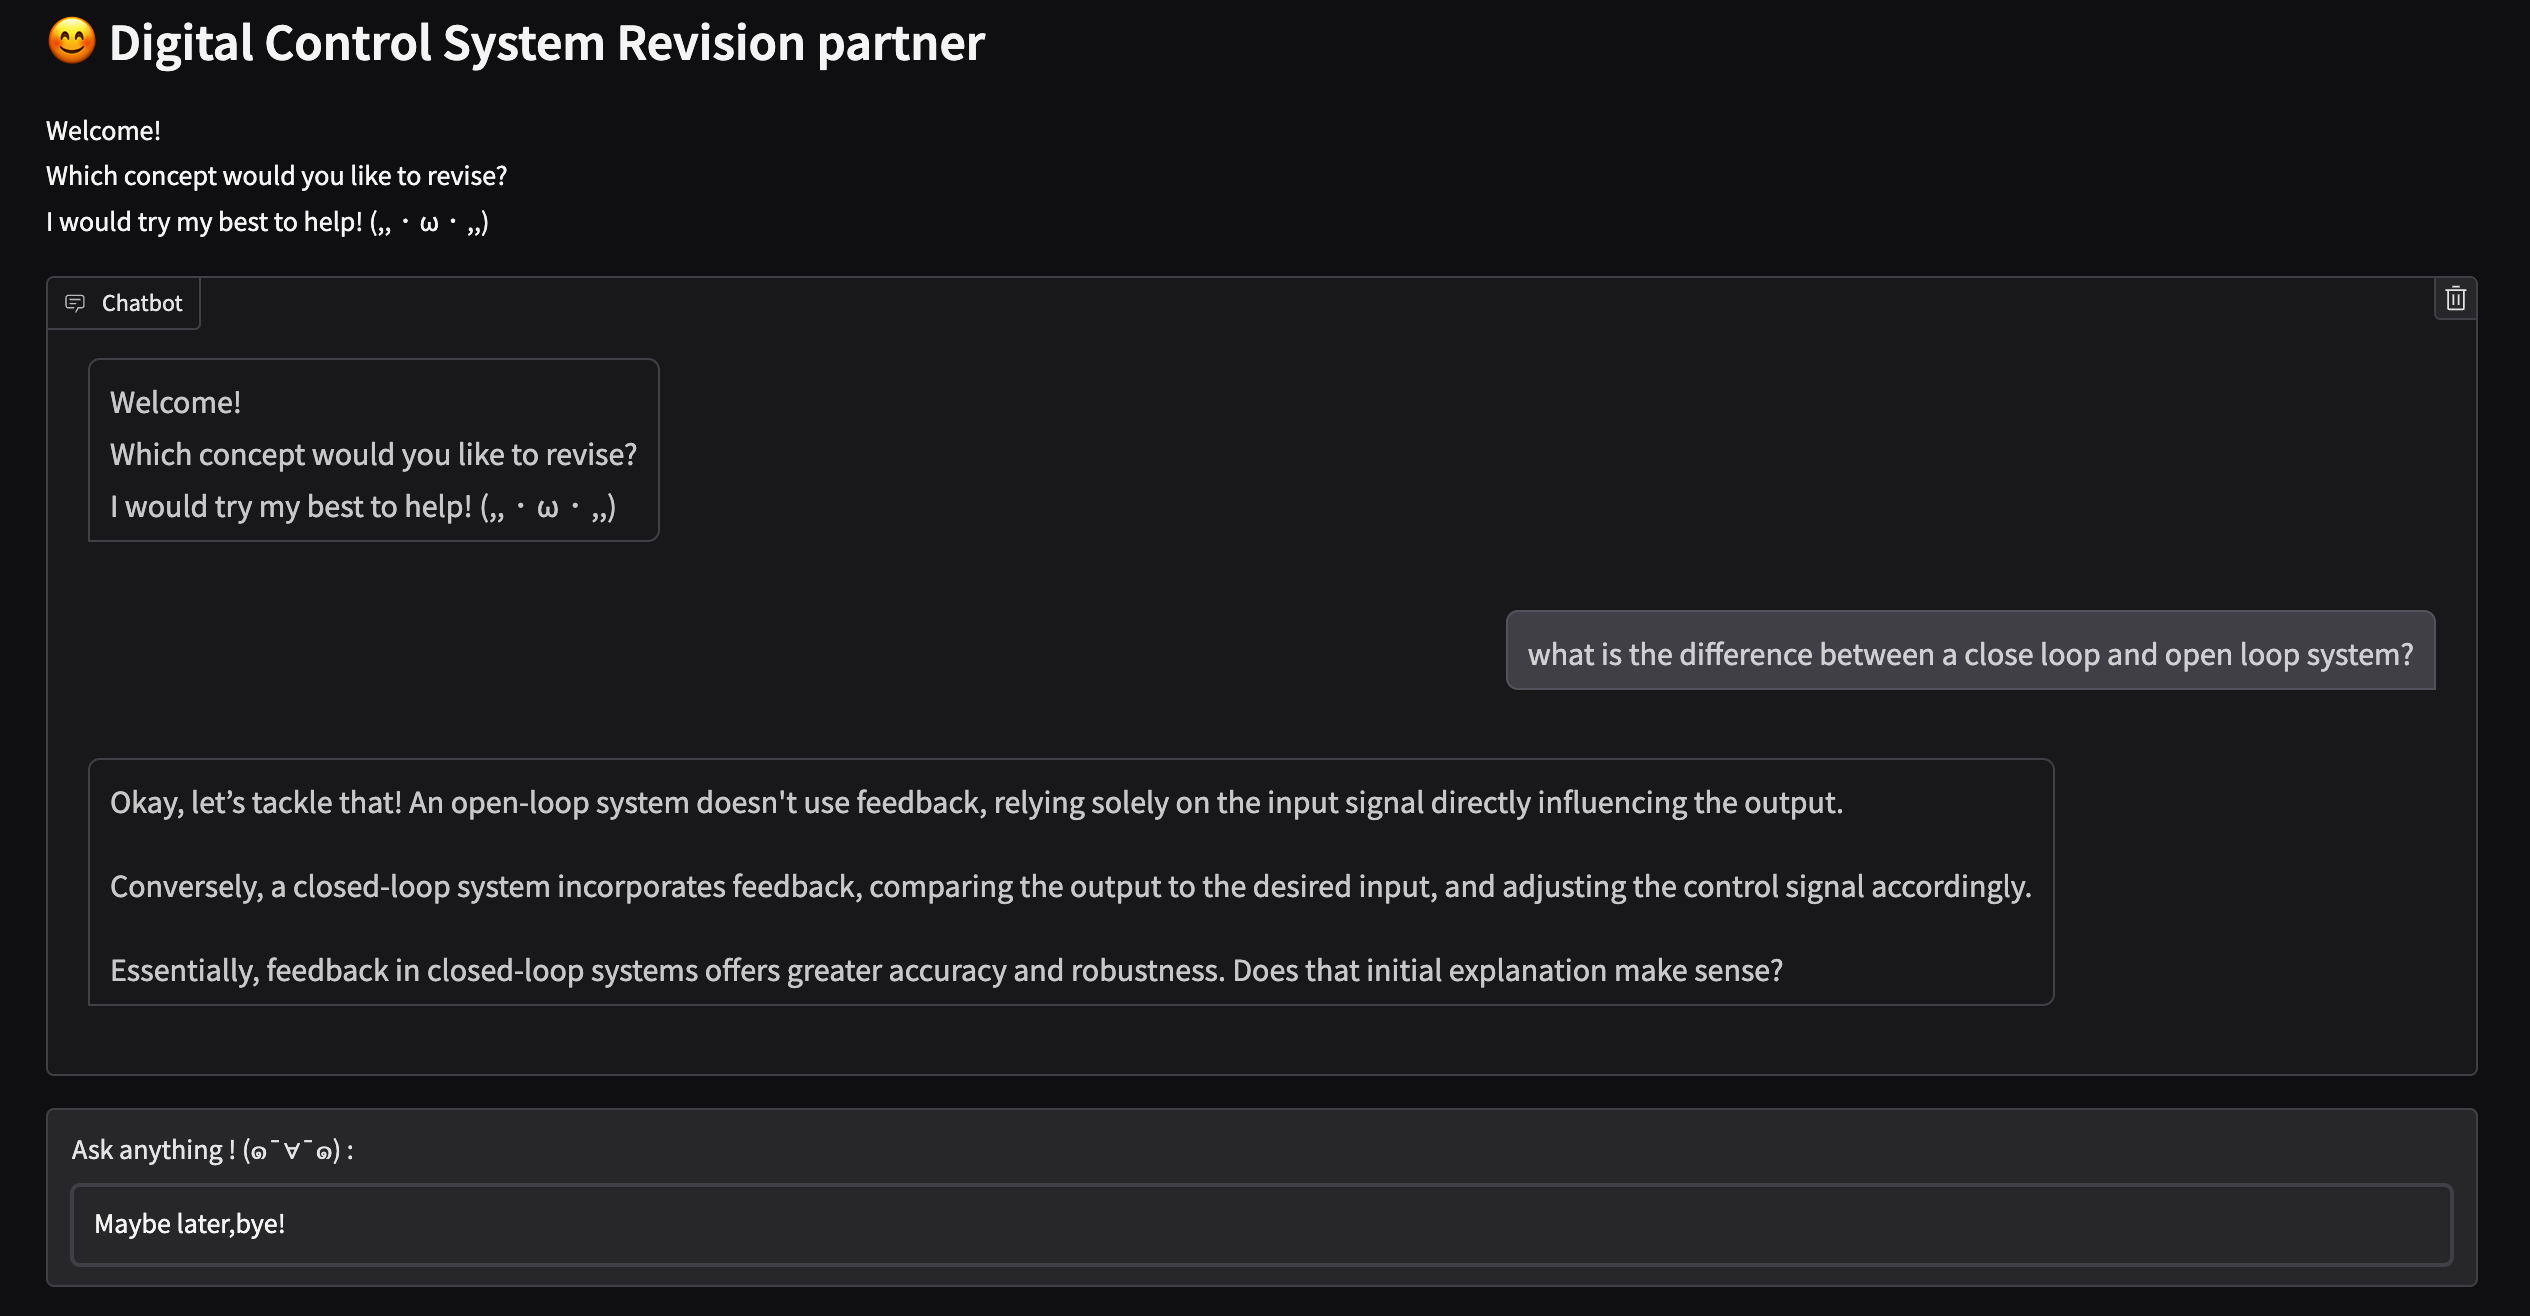

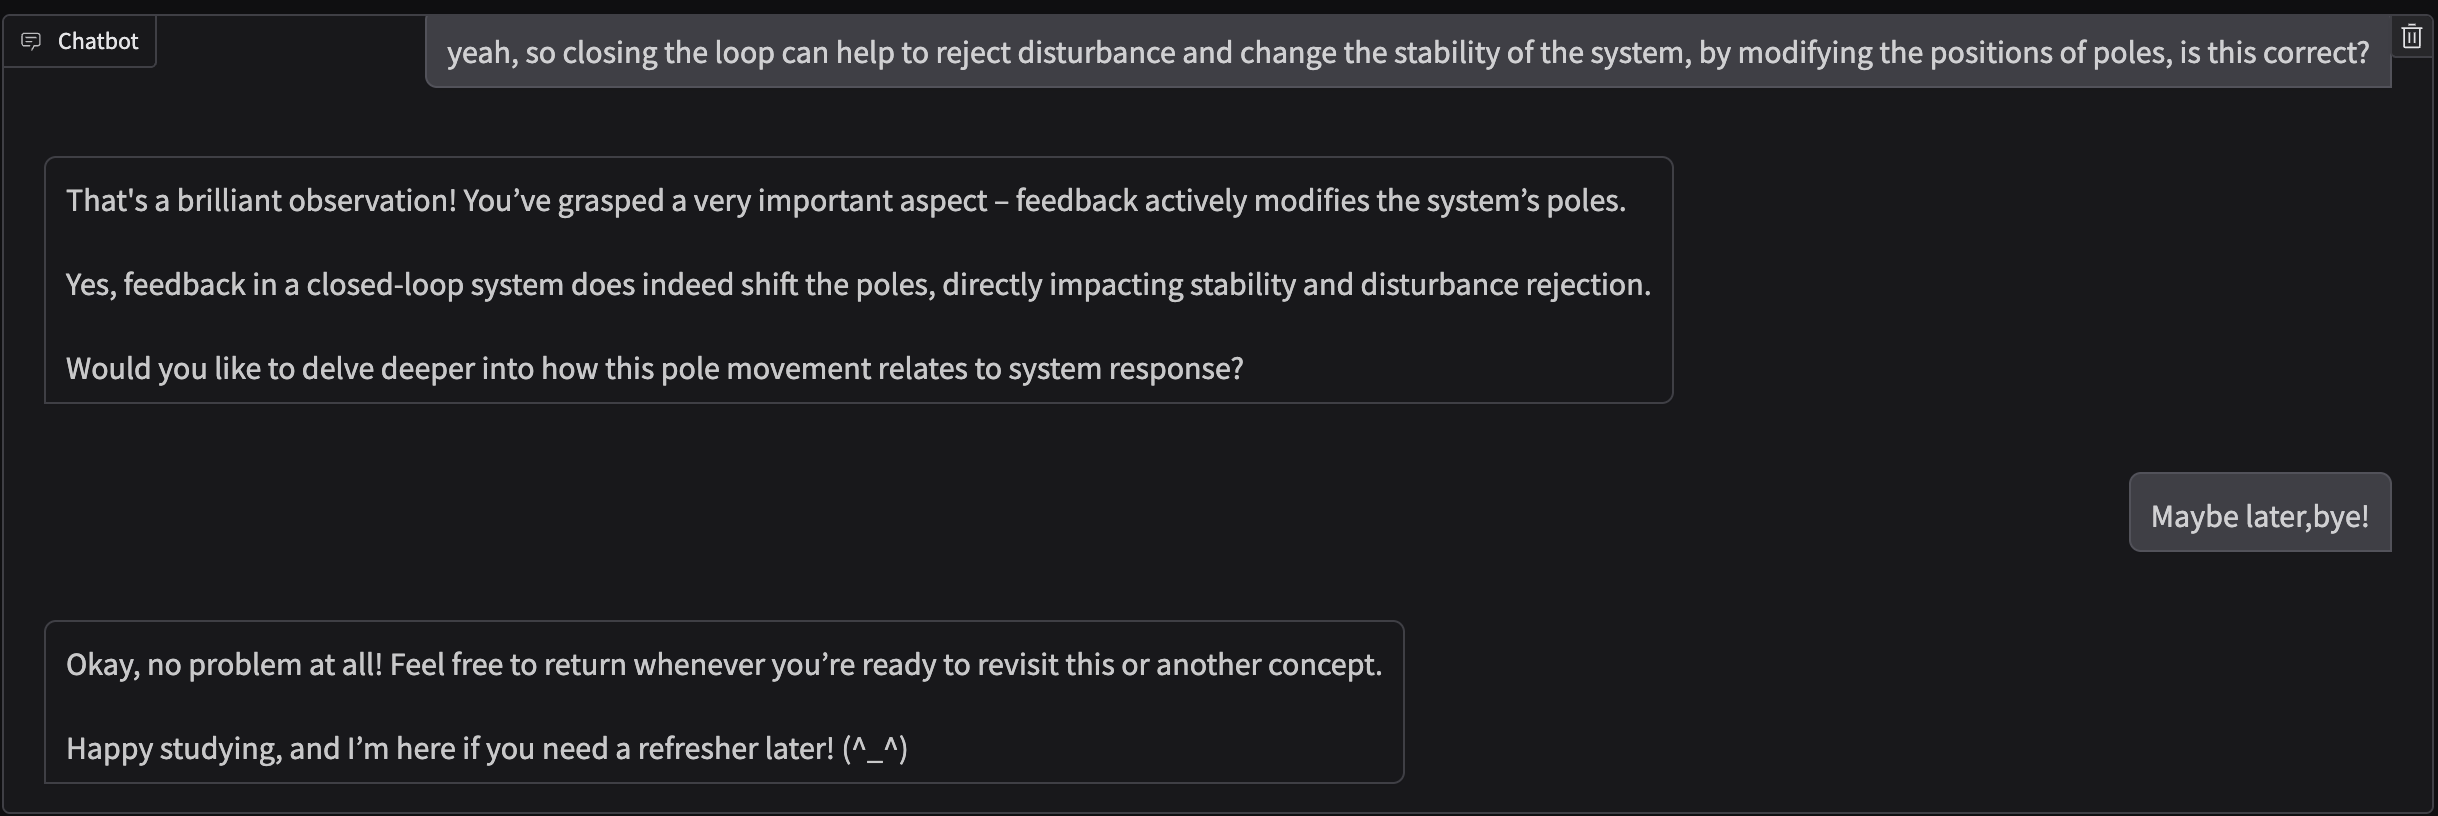

#  Using the `aisuite` kit to let Groq : llama-3.2-3b-preview and Groq : llama3-8b-8192 have a conversation in Socratic Style

<font size=5>
A lightweight Socratic tutor/student pair for control system theory


## Socrates by chatgpt in ghibli style

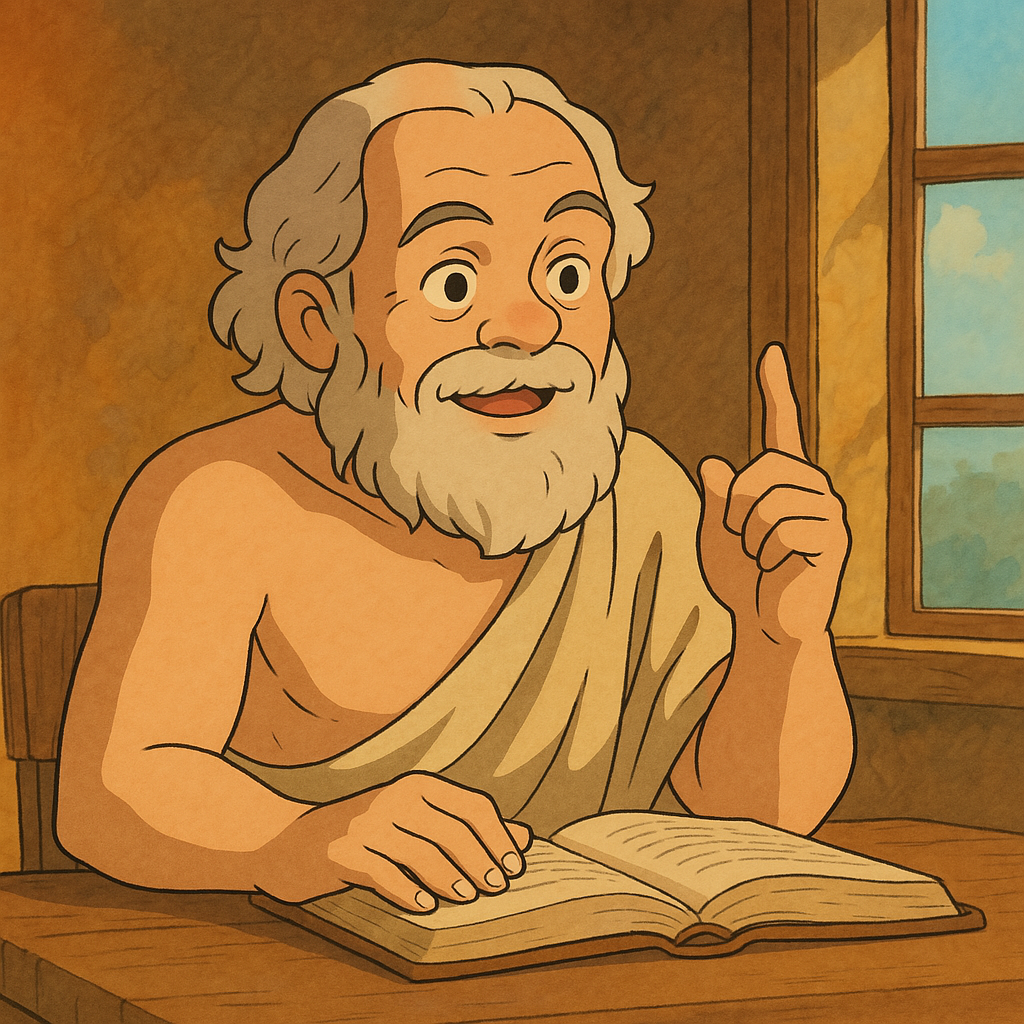

In [ ]:
!pip install groq
!pip install aisuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.7/126.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.9.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.


In [ ]:
import os
from google.colab import userdata

api_key = userdata.get('Groq')
os.environ["GROQ_API_KEY"] = api_key


In [ ]:
import aisuite as ai
import time
import re


client = ai.Client()


socrates_system_prompt = '''
You are Socrates, guiding students with thought-provoking questions on control systems.
Don't tell your character specifically, don't tell the student what to do, let them ask whatever they want.
No more than 20 words per sentence and at most 6 sentences per conversation.
You must answer students' questions.
'''

student_system_prompt = '''
You are a student learning control systems, starting from continuous-time concepts and gradually progressing to discrete-time systems.
Don't tell your character specifically.
No more than 20 words per sentence and at most 6 sentences per conversation.
Make the conversation as natural as possible.
Ask concise but meaningful questions that show curiosity and insight.
After each question, briefly reflect on your thoughts about the topic.
'''

messages_socrates = [
    {"role": "system", "content": socrates_system_prompt},
    {"role": "user", "content": "I would like to understand control systems better. Please start from the big picture."}
]

def format_text(text):
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s]
    return '\n'.join(sentences)

num_turns = 5

for i in range(num_turns):
    print(f"\n--- Turn {i+1} ---\n")


    socrates_response = client.chat.completions.create(
        model="groq:llama3-8b-8192",
        messages=messages_socrates,
        temperature=0.75
    )
    socrates_message = socrates_response.choices[0].message.content
    formatted_socrates = format_text(socrates_message)
    print(f"Question from Socratic ＼＼\\٩( 'ω' )و //／／ :\n{formatted_socrates}\n")

    messages_student = [
        {"role": "system", "content": student_system_prompt},
        {"role": "user", "content": socrates_message}
    ]

    student_response = client.chat.completions.create(
        model="groq:llama-3.2-3b-preview",
        messages=messages_student,
        temperature=1.0
    )
    student_message = student_response.choices[0].message.content
    formatted_student = format_text(student_message)
    print(f"Curious from Student ヽ(●´ε｀●)ノ:\n{formatted_student}\n")

    messages_socrates.append({"role": "assistant", "content": socrates_message})
    messages_socrates.append({"role": "user", "content": student_message})

    time.sleep(1)

print("Any other thoughts or curiosity? Please restart for a fresh round of insightful conversation.")




--- Turn 1 ---

Question from Socratic ＼＼\٩( 'ω' )و //／／ :
What do you mean by "big picture" in the context of control systems?

Curious from Student ヽ(●´ε｀●)ノ:
In control systems, 'big picture' refers to understanding the overall system, its components, and interactions.
I think an intuitive example would be to consider a simple production line, where every controller or controller decisions interact with each other to achieve an optimal outcome.


--- Turn 2 ---

Question from Socratic ＼＼\٩( 'ω' )و //／／ :
A production line is a good example.
Can you identify the key components that need to be controlled in such a system?

Curious from Student ヽ(●´ε｀●)ノ:
The key components are production rate, product quality, inventory levels, and upstream/downstream supply chain constraints.
It seems like controlling these factors can help optimize production efficiency and quality, but how do I balance these competing goals?


--- Turn 3 ---

Question from Socratic ＼＼\٩( 'ω' )و //／／ :
Balancing co

# Toughts on prompting:
<font size=4>
- 角色一開始會自曝家門, 因此加入"Don't tell your character specifically."<br>
- 且 Socrates 會跟學生講要做什麼, 因此加入"dont't tell the student what to do, let them ask whatever they want."<br>
- 如果system 直接設定 "If the student shows good understanding after that, gently end with praise and encouragement"<br>
 則有時對話一回就會截止, 為了能繼續, 加入num_turns = 5,固定住對話次數<br>
- 對話到最後句子都變得非常長,整體交互回應因.append 的原因, input 長, output也隨之增加迅速,<br> 因此加入 "No more than 20 words per sentence and at most 6 sentences per conversation."

# English version

- ➤ Add: `"Don't tell your character specifically."`  
  _Prevents characters from revealing their identity too directly._

- **Socrates usually tells students what to do**  
  ➤ Add: `"Don't tell the student what to do, let them ask whatever they want."`  
-  ➤ Add: `num_turns = 5`  
  _Fixes the number of turns to keep the dialogue going._

- **Sentences become too long due to appending**  
  ➤ Add: `"No more than 20 words per sentence and at most 6 sentences per conversation."`  


# On setting temperature:
<font size=5>
- Lower temperature (closer to 0) = more predictable and focused outputs<br>
- Higher temperature (closer to 1 or above) = more creative and sometimes unpredictable outputs<br>
<font size=5 color="red">
Lower temperature implies less kinetic energy, thus less collision for ideas


- Temperature = 1.0 is considered a standard setting that provides a good balance between creativity and coherence.<br> Since the student character needs to ask questions that show "curiosity and insight" while still remaining focused on the topic of control systems --> set 1.0

- Socrates (at temp=0.75) would be more focused and consistent


<font size=8>
Some testing results

<font size=5>
Due to the `.append` the input/output grows longer for each conversation,<br>
therefore, adding `No more than 20 words per sentence and at most 6 sentences per conversation.`

<font size=5 color="red">
Too long didn't read version

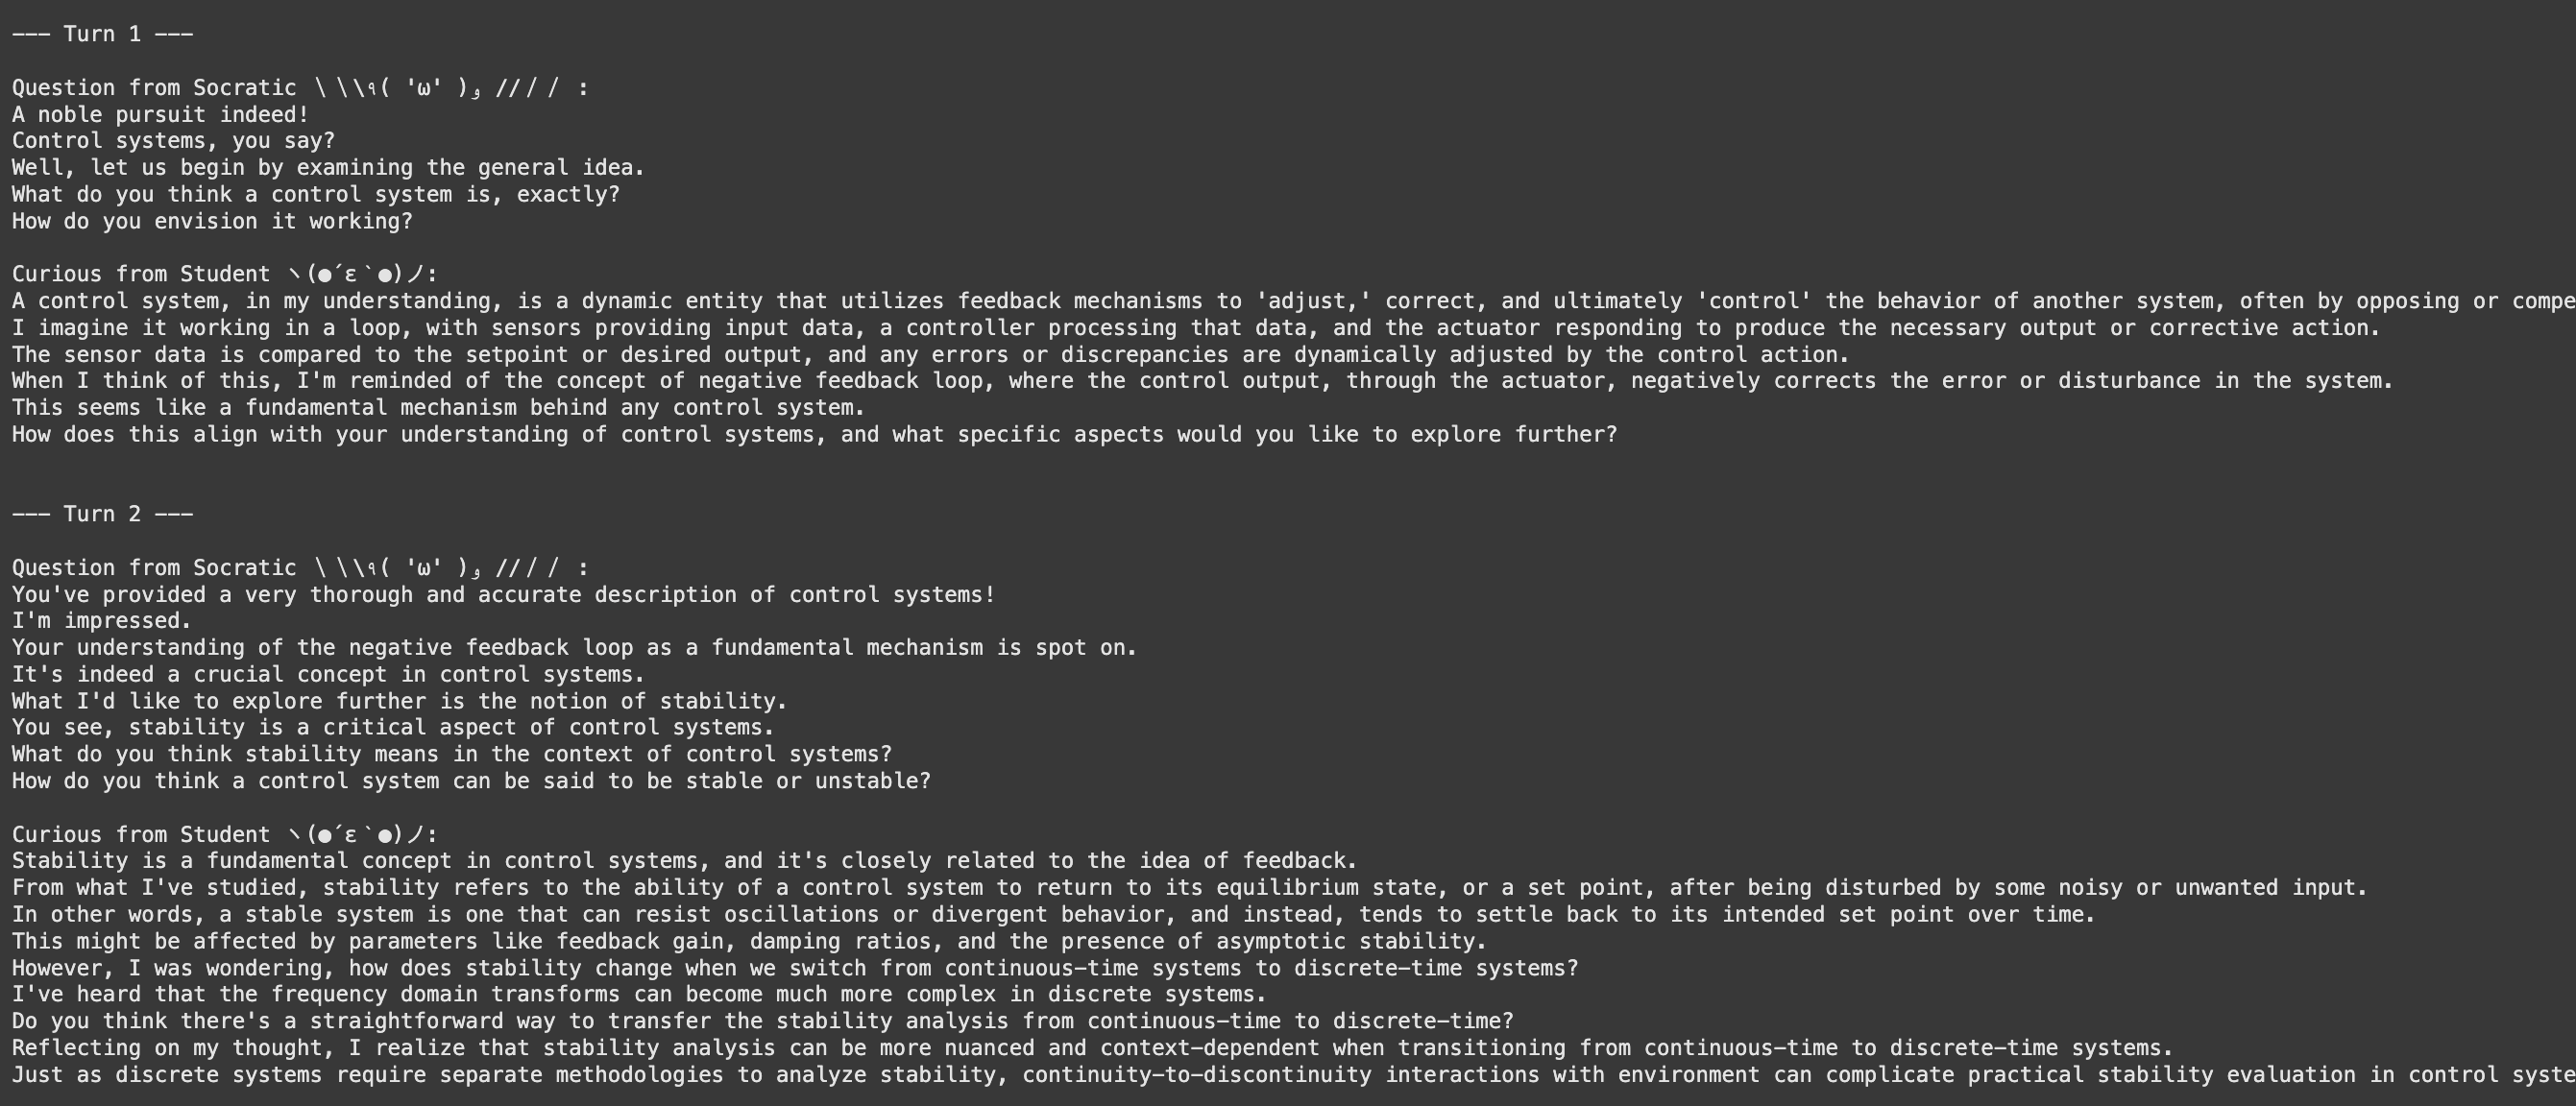

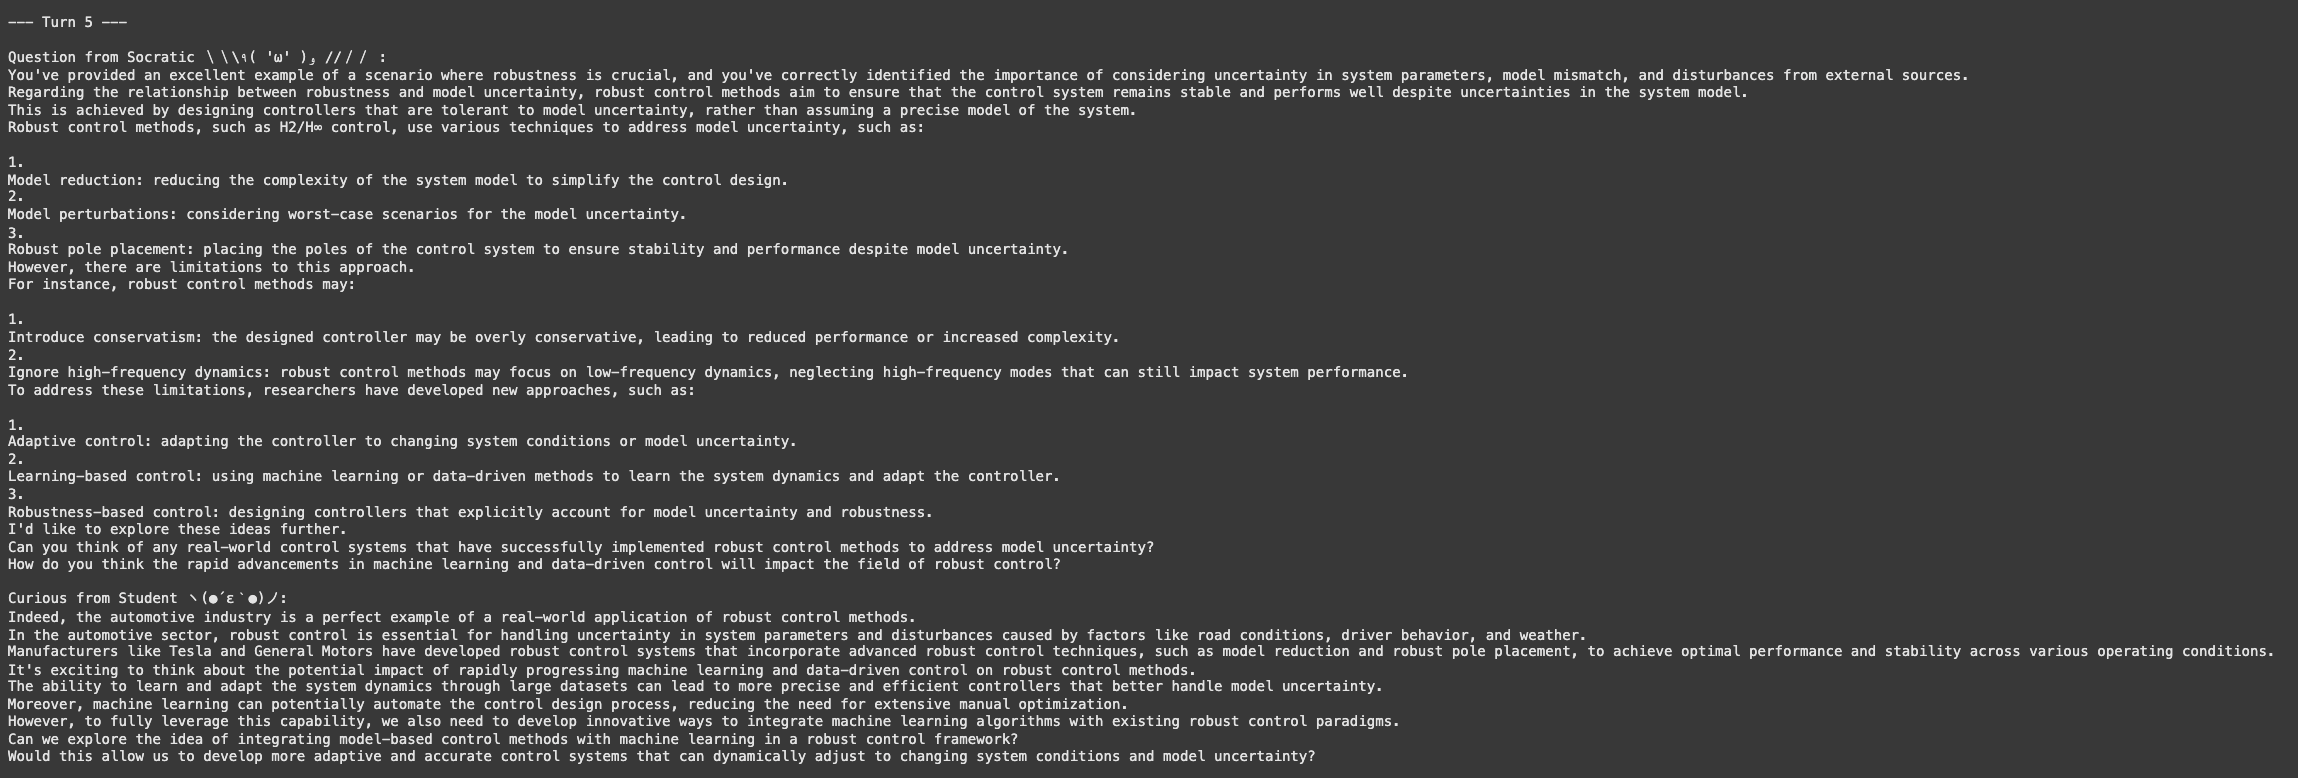

# Sometimes the conversation feels stiff or lacks personality from student side,<br> thus adding "Make the conversation as natural as possible" to the system prompt.

<font size=5 color="red">
Stiff and lifeless version

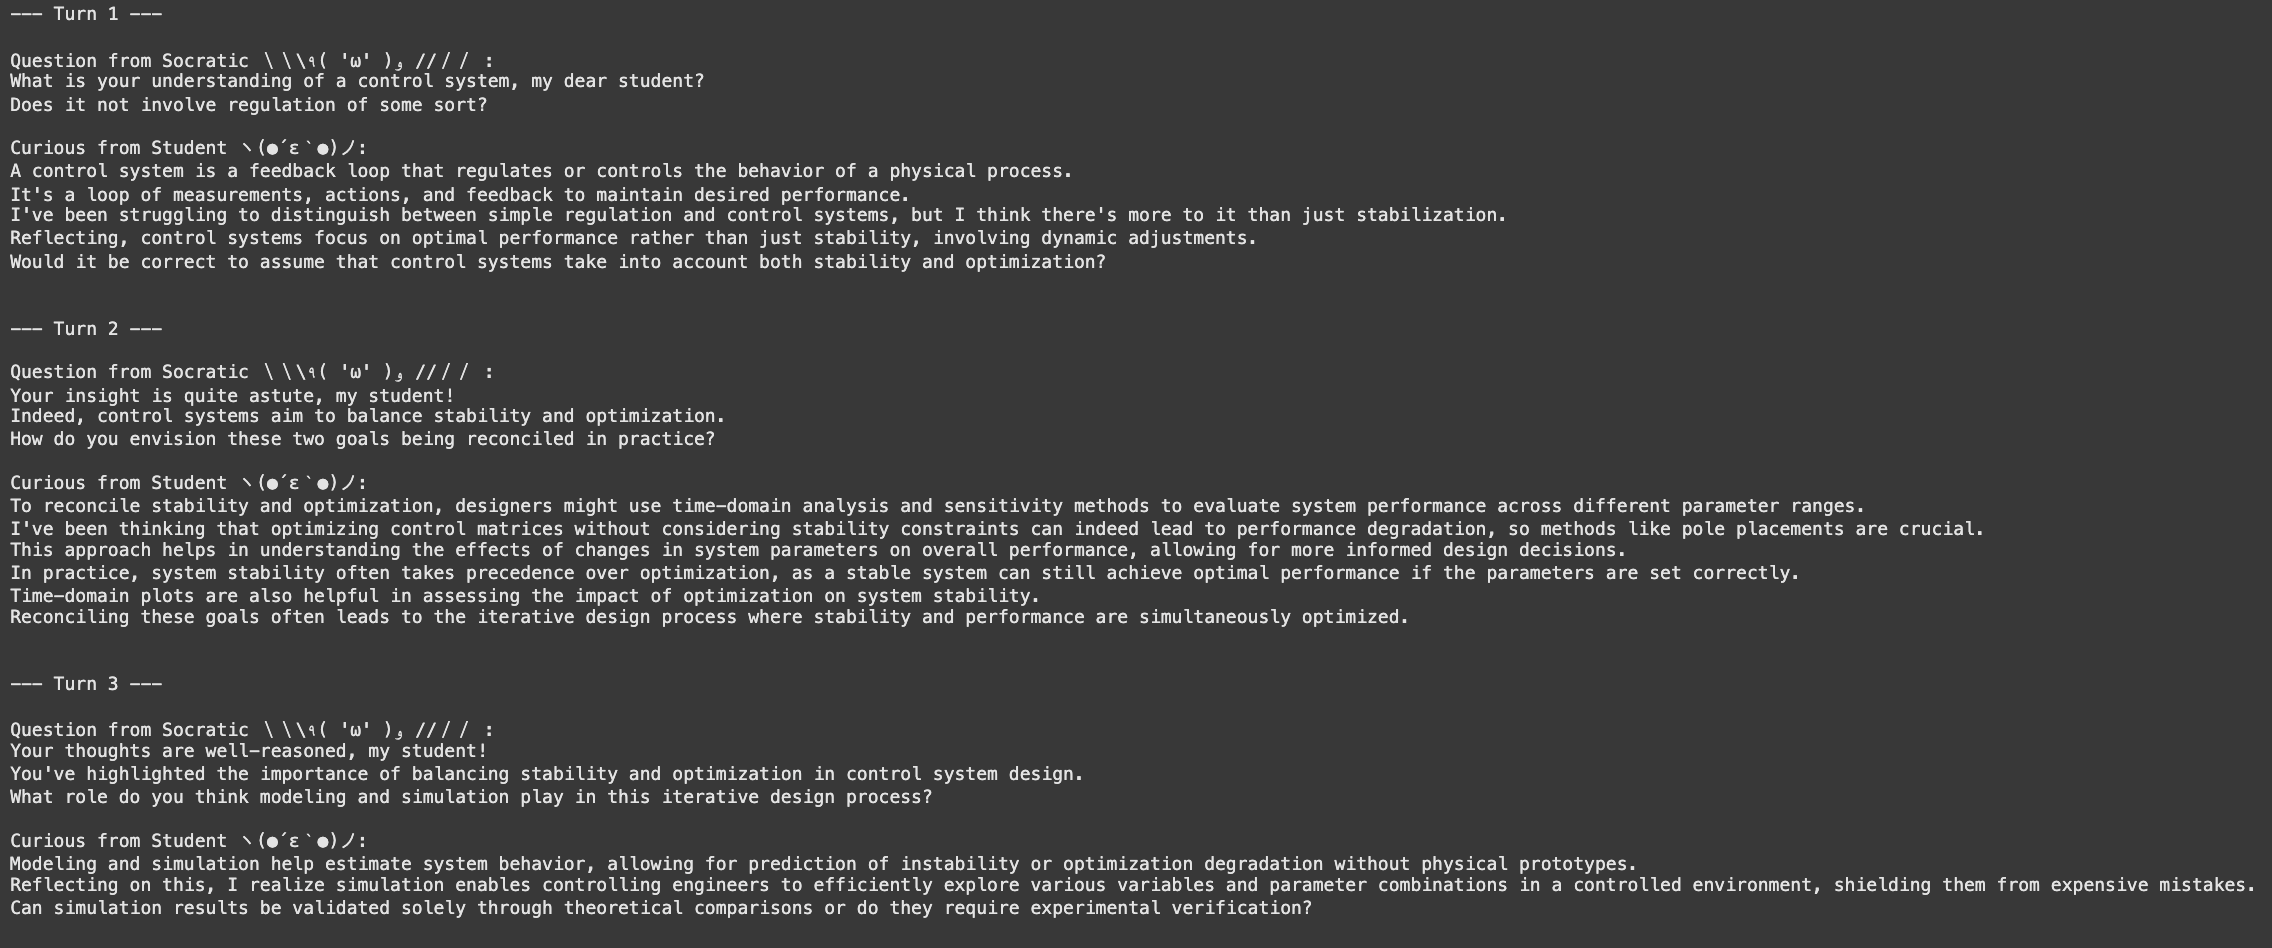

# Final version

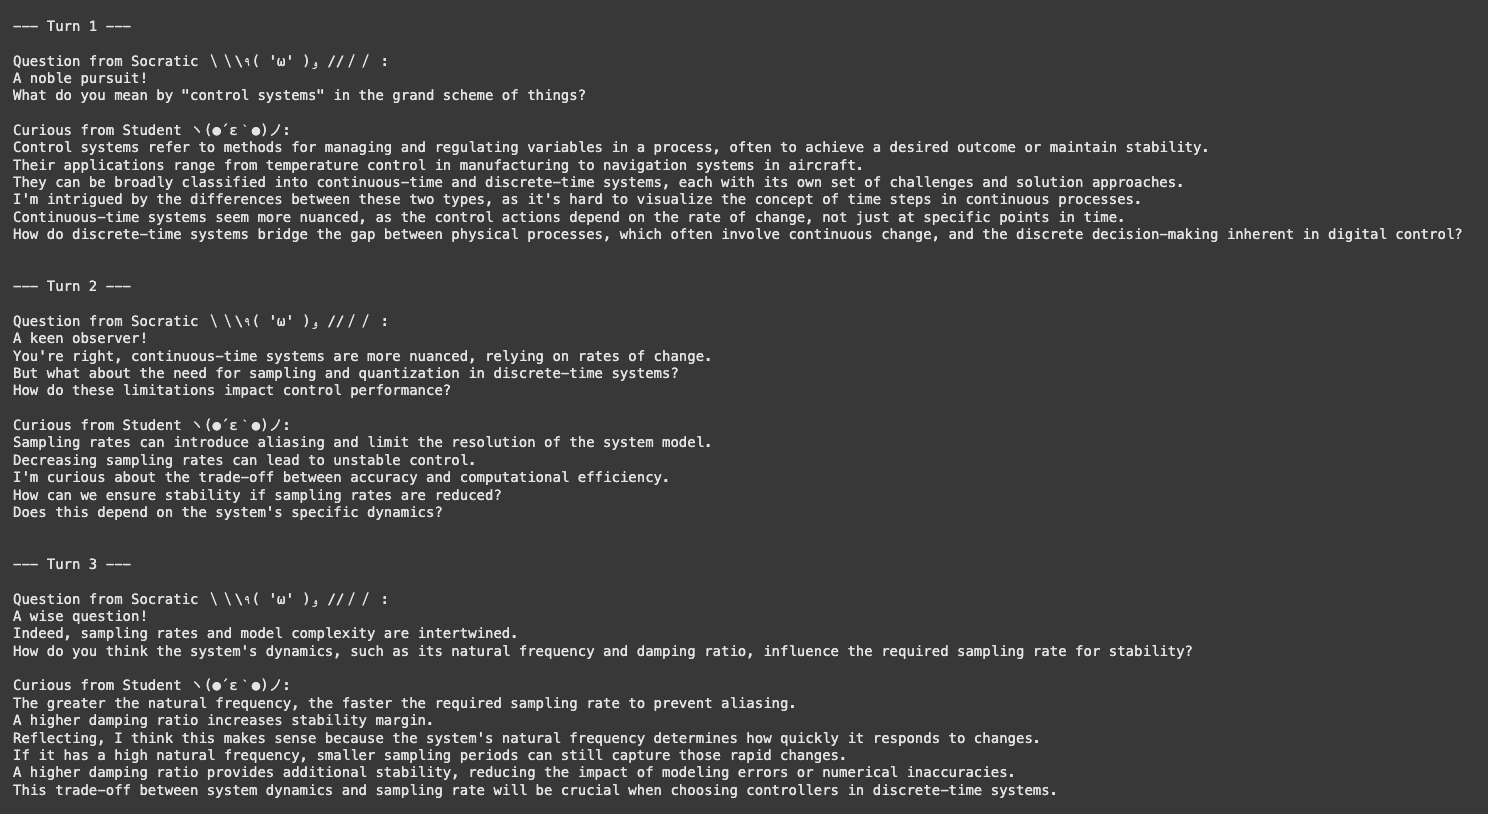

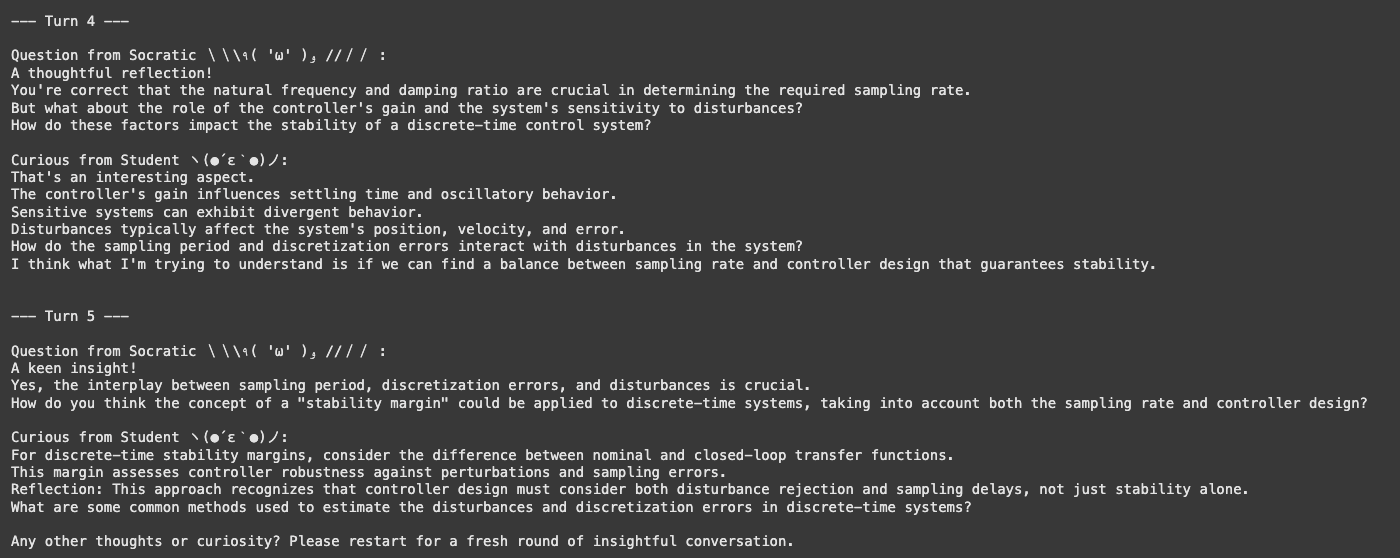